# Phân tích mức độ quan tâm điểm đến theo mùa

Kết quả đo **mức độ quan tâm trên nội dung trực tuyến**, không thay thế thống kê lượng khách du lịch thực tế.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent
data_root = project_root / 'data'
analysis_dir = data_root / 'analysis'
analysis_dir.mkdir(exist_ok=True)


In [2]:
sources = []
for raw_file in data_root.glob('*/rawdata.csv'):
    if raw_file.parent.name == 'analysis':
        continue
    frame = pd.read_csv(raw_file)
    frame['source'] = raw_file.parent.name
    sources.append(frame)

articles = pd.concat(sources, ignore_index=True, sort=False)
articles.shape

(200, 13)

In [3]:
DESTINATIONS = {
    'Hà Nội': ['hà nội', 'hanoi'], 'Hạ Long': ['hạ long', 'ha long'],
    'Sa Pa': ['sa pa', 'sapa'], 'Ninh Bình': ['ninh bình', 'ninh binh'],
    'Đà Nẵng': ['đà nẵng', 'da nang'], 'Hội An': ['hội an', 'hoi an'],
    'Huế': ['huế', 'hue'], 'Đà Lạt': ['đà lạt', 'da lat'],
    'Nha Trang': ['nha trang'], 'Phú Quốc': ['phú quốc', 'phu quoc'],
    'TP. Hồ Chí Minh': ['hồ chí minh', 'ho chi minh', 'sài gòn', 'sai gon'],
    'Cần Thơ': ['cần thơ', 'can tho'], 'Hà Giang': ['hà giang', 'ha giang'],
    'Phong Nha': ['phong nha'], 'Mũi Né': ['mũi né', 'mui ne']
}
THEMES = {
    'Biển - đảo': ['biển', 'beach', 'đảo', 'island'],
    'Văn hóa - di sản': ['di sản', 'heritage', 'văn hóa', 'cố đô', 'bảo tàng'],
    'Thiên nhiên - khám phá': ['núi', 'hang', 'trekking', 'thiên nhiên', 'thác'],
    'Ẩm thực': ['ẩm thực', 'món ăn', 'food', 'cà phê', 'coffee'],
    'Nghỉ dưỡng': ['resort', 'nghỉ dưỡng', 'wellness', 'spa'],
    'Lễ hội - sự kiện': ['lễ hội', 'festival', 'sự kiện', 'event']
}

def label_from_text(text, dictionary):
    text = str(text).lower()
    return next((label for label, terms in dictionary.items() if any(term in text for term in terms)), 'Khác')


In [4]:
# Dùng cùng luồng làm sạch/khử trùng/gán nhãn với chế độ chạy tự động.
# Các tệp label_review.csv và duplicate_articles.csv được tạo tại data/analysis/.
import sys
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from analysis_pipeline import normalize_articles

articles = normalize_articles()
articles[['source', 'title', 'destination', 'travel_theme', 'season', 'views_per_day']].head()

,source,title,destination,travel_theme,season,views_per_day
0,VNTRIP,ATADI.VN – MỞ RA KỶ NGUYÊN DU LỊCH MỚI TRONG H...,Khác,Khác,Đông,5.940594
1,VNTRIP,Vntrip TMS – Giải pháp quản trị công tác và du...,Khác,Khác,Đông,3.833333
2,VNTRIP,Chuyện chiếc bánh mì và bài học về sự tận tâm ...,Khác,Văn hóa - di sản,Đông,2.884793
3,VNTRIP,EMS – “Trợ lý tài chính AI” giúp doanh nghiệp ...,Khác,Khác,Đông,3.437788
4,VNTRIP,VNTRIP TMS – GIẢI PHÁP TỐI ƯU CHI PHÍ CÔNG TÁC...,Khác,Khác,Đông,2.619048


In [5]:
season_stats = (articles[(articles['destination'] != 'Khác') & (articles['source'] == 'VNTRIP')]
    .groupby(['destination', 'season'], observed=True, as_index=False)
    .agg(article_count=('article_id', 'count'), total_views=('view_count', 'sum'),
         median_views_per_day=('views_per_day', 'median')))
season_stats.to_csv(analysis_dir / 'destination_season_stats.csv', encoding='utf-8-sig', index=False)
season_stats.sort_values('median_views_per_day', ascending=False).head(15)

,destination,season,article_count,total_views,median_views_per_day
0,Huế,Hè,1,7300.0,6.207483
25,Đà Lạt,Hè,2,8100.0,4.357620
7,Hà Nội,Thu,2,2700.0,2.873606
28,Đà Nẵng,Xuân,2,6724.0,2.791971
19,Sa Pa,Thu,3,11600.0,2.671480
9,Hạ Long,Thu,2,1840.0,2.525523
17,Phú Quốc,Đông,2,5000.0,2.505313
15,Ninh Bình,Hè,1,2800.0,2.486679
4,Hà Giang,Hè,1,770.0,1.925000
12,Hội An,Hè,1,1700.0,1.468048


In [6]:
theme_stats = (articles[articles['destination'] != 'Khác']
    .groupby(['source', 'destination', 'travel_theme', 'season'], observed=True, as_index=False)
    .agg(article_count=('article_id', 'count'), total_views=('view_count', 'sum'),
         median_views_per_day=('views_per_day', 'median')))
theme_stats.to_csv(analysis_dir / 'destination_theme_stats.csv', encoding='utf-8-sig', index=False)
theme_stats.sort_values(['source', 'article_count'], ascending=[True, False]).head(15)

,source,destination,travel_theme,season,article_count,total_views,median_views_per_day
8,VNTRIP,Hà Nội,Khác,Đông,6,9759.0,1.027892
33,VNTRIP,Đà Lạt,Khác,Thu,4,4475.0,0.778414
34,VNTRIP,Đà Lạt,Khác,Đông,4,10494.0,1.775526
5,VNTRIP,Hà Giang,Khác,Đông,3,5290.0,0.828937
24,VNTRIP,Sa Pa,Khác,Thu,3,11600.0,2.671480
25,VNTRIP,Sa Pa,Khác,Đông,3,6898.0,0.753623
31,VNTRIP,Đà Lạt,Khác,Xuân,3,2737.0,0.756800
7,VNTRIP,Hà Nội,Khác,Thu,2,2700.0,2.873606
11,VNTRIP,Hạ Long,Biển - đảo,Thu,2,1840.0,2.525523
15,VNTRIP,Hội An,Khác,Thu,2,3600.0,1.251936


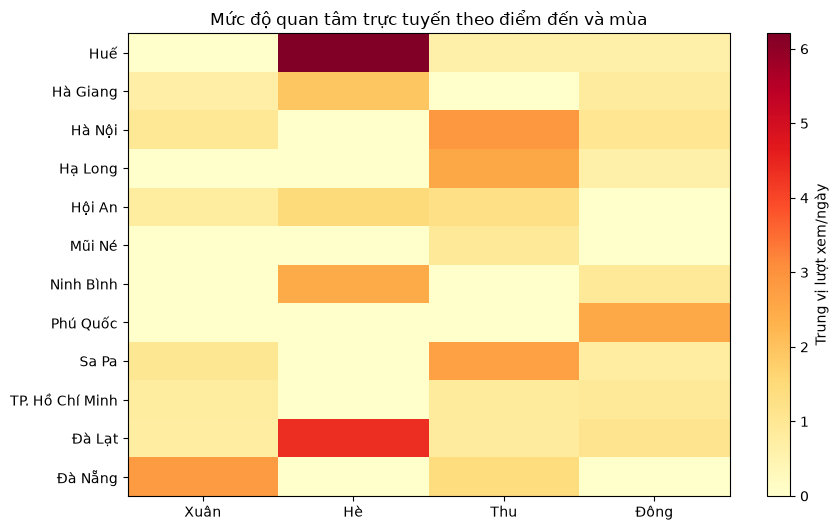

In [7]:
heatmap_data = season_stats.pivot(index='destination', columns='season', values='median_views_per_day').fillna(0)
heatmap_data = heatmap_data.reindex(columns=['Xuân', 'Hè', 'Thu', 'Đông'], fill_value=0)
plt.figure(figsize=(9, max(4, len(heatmap_data) * 0.45)))
plt.imshow(heatmap_data, aspect='auto', cmap='YlOrRd')
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.colorbar(label='Trung vị lượt xem/ngày')
plt.title('Mức độ quan tâm trực tuyến theo điểm đến và mùa')
plt.tight_layout()
plt.show()